In [1]:
##########################################
# Añadir esto al principio de cada ipynb #
##########################################
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/MyDrive/_UOC/tfm-solar-forecasting/')

# Verifica que existan las carpetas esperadas
!ls
# Debes ver 'src' y 'config'

Mounted at /content/drive
checkpoints  data  lightning_logs  README.md	     results
config	     doc   notebooks	   requirements.txt  src


In [2]:
# ============================================================================
# EXPERIMENTO 2: TRANSFERENCIA N-BEATS ENTRE PLANTAS SOLARES
# Pre-entrenamiento sobre 5 plantas fuente → Zero-shot + Fine-tuning en TALASOL
# ============================================================================

import sys
# Añadir src/ al path buscando la raíz del repo desde el directorio actual.
# En Google Colab: montar Drive y hacer os.chdir() al repo ANTES de ejecutar.
#   from google.colab import drive; drive.mount('/content/drive')
#   import os; os.chdir('/content/drive/MyDrive/_MCD/TFM/MUDS-TFM/tfm-solar-forecasting/')
import pathlib as _pl
_root = next(
    (p for p in [_pl.Path.cwd(), *_pl.Path.cwd().parents]
     if (p / 'src').is_dir() and (p / 'data' / 'processed').is_dir()),
    None
)
if _root is None:
    raise RuntimeError(
        f"No se encontró src/. cwd={_pl.Path.cwd()}\n"
        "En Colab: monta Drive y ejecuta os.chdir() al repo antes de %run."
    )
sys.path.insert(0, str(_root / 'src'))
del _pl, _root

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

# Módulos del proyecto
from nbeats_model       import NBeatsForecaster, NBeatsTrainer
from nbeats_data_loader import NBeatsDataset
from evaluation         import ForecastEvaluator

# Módulos del experimento 2
from ex2_transfer.ex2_nbeats_config import (
    PLANTAS_SOURCE, PLANTA_TARGET,
    SMOKE_TEST, SMOKE_MAX_ROWS,
    DATA_DIR, RESULTS_DIR, CHECKPOINTS_DIR,
    DEVICE, SEQ_LENGTH, EXOG_COLS,
    MODEL_CFG, FINETUNE_CFG, FINETUNE_SIZES,
)
from ex2_transfer.nbeats_transfer import (
    load_plant_split,
    build_source_loaders,
    build_target_loaders,
    evaluate,
    save_results_row,
    NBeatsTransferTrainer,
)
from ex1_compare.visualization import (
    plot_diagnostic, plot_timeseries, plot_learning_curves,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Garantizar que existen los directorios de salida
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

print('=' * 80)
print('EXPERIMENTO 2: TRANSFERENCIA N-BEATS')
print(f'Plantas fuente : {PLANTAS_SOURCE}')
print(f'Planta destino : {PLANTA_TARGET}')
print(f'Device         : {DEVICE}')
print(f'Smoke test     : {SMOKE_TEST}')
print(f'SEQ_LENGTH     : {SEQ_LENGTH}h  (1 semana)')
print(f'MODEL_CFG      : {MODEL_CFG}')
print(f'FINETUNE_CFG   : {FINETUNE_CFG}')
print(f'FINETUNE_SIZES : {list(FINETUNE_SIZES.keys())}')
print('=' * 80)

[ex2_nbeats] Entorno: Google Colab | Device: cuda (Tesla T4)
[ex1] Entorno: Google Colab | Device: cuda (Tesla T4)
EXPERIMENTO 2: TRANSFERENCIA N-BEATS
Plantas fuente : ['UPGARNACHA', 'FVARENA', 'NBALBOA', 'RODRI', 'UFMULA']
Planta destino : TALASOL
Device         : cuda
Smoke test     : False
SEQ_LENGTH     : 168h  (1 semana)
MODEL_CFG      : {'n_units': 256, 'n_layers': 4, 'n_blocks': 3, 'batch_size': 128, 'max_epochs': 50, 'patience': 10, 'lr': 0.001}
FINETUNE_CFG   : {'max_epochs': 30, 'patience': 5, 'lr_factor': 0.1}
FINETUNE_SIZES : ['zero_shot', '1_semana', '1_mes', '3_meses']


In [3]:
# ============================================================================
# KEEP-ALIVE COLAB — Evita desconexión por inactividad durante entrenamientos largos
# Ejecutar esta celda UNA VEZ antes del entrenamiento (solo tiene efecto en Colab)
# ============================================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from IPython.display import display, Javascript
    display(Javascript("""
    function ClickConnect(){
        console.log("Keep-alive: click en 'Conectar'");
        document.querySelector("colab-toolbar-button#connect")?.click();
    }
    var interval = setInterval(ClickConnect, 60000);
    console.log("Keep-alive iniciado (interval id=" + interval + ")");
    """))
    print("✓ Keep-alive activado (click automático cada 60 s)")
else:
    print("Entorno local — keep-alive no necesario")

<IPython.core.display.Javascript object>

✓ Keep-alive activado (click automático cada 60 s)


In [4]:
# ============================================================================
# 1. CARGA DE DATOS
# ============================================================================

print('[1/7] Cargando datos...')

df_train = pd.read_csv(DATA_DIR / 'train.csv')
df_val   = pd.read_csv(DATA_DIR / 'val.csv')
df_test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'  Train: {len(df_train):,} registros')
print(f'  Val:   {len(df_val):,} registros')
print(f'  Test:  {len(df_test):,} registros')
print(f'  Plantas disponibles: {sorted(df_train["planta_nombre"].unique())}')

# Verificar que todas las plantas están presentes
todas = PLANTAS_SOURCE + [PLANTA_TARGET]
plantas_disponibles = set(df_train['planta_nombre'].unique())
for p in todas:
    if p not in plantas_disponibles:
        raise ValueError(f'Planta {p!r} no encontrada en train.csv')

print(f'\nShapes por planta (train):')
for p in todas:
    df_p = load_plant_split(df_train, p, SMOKE_TEST, SMOKE_MAX_ROWS)
    print(f'  {p}: {len(df_p):,} filas')

print('\n[1/7] OK')

[1/7] Cargando datos...
  Train: 50,917 registros
  Val:   6,780 registros
  Test:  8,922 registros
  Plantas disponibles: ['FVARENA', 'NBALBOA', 'RODRI', 'TALASOL', 'UFMULA', 'UPGARNACHA']

Shapes por planta (train):
  UPGARNACHA: 6,050 filas
  FVARENA: 8,978 filas
  NBALBOA: 8,955 filas
  RODRI: 8,978 filas
  UFMULA: 8,978 filas
  TALASOL: 8,978 filas

[1/7] OK


In [5]:
# ============================================================================
# 2. PRE-ENTRENAMIENTO MULTI-PLANTA (plantas fuente)
# ============================================================================
import time

print('[2/7] Pre-entrenamiento N-BEATS multi-planta...')
print('=' * 80)

ckpt_pretrained = CHECKPOINTS_DIR / 'pretrained.pt'

# ── RESUME: si ya existe el checkpoint, cargar y saltar pretraining ───────────
_resumed = False
if ckpt_pretrained.exists():
    try:
        print(f'  ✓ Checkpoint encontrado — skip pretraining')
        ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
        model = NBeatsForecaster(
            seq_length  = SEQ_LENGTH,
            n_exog      = len(EXOG_COLS),
            stack_types = ['trend', 'seasonality', 'generic'],
            n_blocks    = MODEL_CFG['n_blocks'],
            n_units     = MODEL_CFG['n_units'],
            n_layers    = MODEL_CFG['n_layers'],
        )
        model.load_state_dict(ckpt['model_state_dict'])
        model.to(DEVICE)
        transfer_trainer    = NBeatsTransferTrainer(model, DEVICE)
        transfer_trainer._pretrain_state = ckpt['model_state_dict']
        pretrain_hist   = {'train': [], 'val': []}
        pretrain_time_s = 0.0
        print(f'  Modelo cargado: {ckpt_pretrained}')
        print('[2/7] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        ckpt_pretrained.unlink(missing_ok=True)
if not _resumed:
    # DataLoaders multi-planta
    print('\nConstruyendo DataLoaders de plantas fuente:')
    train_loader, val_loader, scalers_source = build_source_loaders(
        plantas_source = PLANTAS_SOURCE,
        df_train       = df_train,
        df_val         = df_val,
        exog_cols      = EXOG_COLS,
        seq_length     = SEQ_LENGTH,
        batch_size     = MODEL_CFG['batch_size'],
        smoke_test     = SMOKE_TEST,
        max_rows       = SMOKE_MAX_ROWS,
    )

    # Crear modelo
    model = NBeatsForecaster(
        seq_length  = SEQ_LENGTH,
        n_exog      = len(EXOG_COLS),
        stack_types = ['trend', 'seasonality', 'generic'],
        n_blocks    = MODEL_CFG['n_blocks'],
        n_units     = MODEL_CFG['n_units'],
        n_layers    = MODEL_CFG['n_layers'],
    )

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'\nModelo N-BEATS: {n_params:,} parámetros')
    print(f'  n_units={MODEL_CFG["n_units"]}  n_layers={MODEL_CFG["n_layers"]}  '
          f'n_blocks={MODEL_CFG["n_blocks"]}  n_exog={len(EXOG_COLS)}')

    # Pre-entrenamiento
    transfer_trainer = NBeatsTransferTrainer(model, DEVICE)
    print(f'\nPre-entrenando {MODEL_CFG["max_epochs"]} epochs (patience={MODEL_CFG["patience"]})...')
    t0 = time.time()
    pretrain_hist = transfer_trainer.pretrain(train_loader, val_loader, MODEL_CFG)
    pretrain_time_s = time.time() - t0
    print(f'  Tiempo pretraining: {pretrain_time_s/60:.1f} min ({pretrain_time_s:.0f} s)')

    # Guardar checkpoint
    torch.save({
        'model_state_dict':  transfer_trainer._pretrain_state,
        'model_cfg':         MODEL_CFG,
        'plantas_source':    PLANTAS_SOURCE,
        'seq_length':        SEQ_LENGTH,
        'exog_cols':         EXOG_COLS,
    }, ckpt_pretrained)
    print(f'  ✓ Checkpoint guardado: {ckpt_pretrained}')

    # Curvas de aprendizaje del pretraining
    plot_learning_curves(
        [pretrain_hist], PLANTA_TARGET, 'nbeats-pretrain',
        save_dir=RESULTS_DIR / 'figures'
    )
    print('[2/7] OK')

[2/7] Pre-entrenamiento N-BEATS multi-planta...
  ✓ Checkpoint encontrado — skip pretraining
  Modelo cargado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex2_transfer/nbeats/pretrained.pt
[2/7] OK (desde checkpoint)


In [6]:
# ============================================================================
# 3. EVALUACIÓN ZERO-SHOT EN TALASOL
# ============================================================================

print('[3/7] Zero-shot en TALASOL...')
print('=' * 80)

preds_zs_csv = CHECKPOINTS_DIR / 'preds_zero_shot.csv'

# ── RESUME ────────────────────────────────────────────────────────────────────
_resumed = False
if preds_zs_csv.exists():
    try:
        print(f'  ✓ Predicciones zero-shot encontradas — skip inferencia')
        df_pred_zs = pd.read_csv(preds_zs_csv)
        if 'timestamp' in df_pred_zs.columns:
            df_pred_zs['timestamp'] = pd.to_datetime(df_pred_zs['timestamp'])
        print('[3/7] OK (desde CSV)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        preds_zs_csv.unlink(missing_ok=True)
if not _resumed:
    _, val_loader_tgt, test_loader_tgt, test_ds_tgt, scaler_y_tgt = build_target_loaders(
        planta_target    = PLANTA_TARGET,
        df_train         = df_train,
        df_val           = df_val,
        df_test          = df_test,
        exog_cols        = EXOG_COLS,
        seq_length       = SEQ_LENGTH,
        batch_size       = MODEL_CFG['batch_size'],
        n_finetune_hours = 0,
        smoke_test       = SMOKE_TEST,
        max_rows         = SMOKE_MAX_ROWS,
    )

    ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(DEVICE)
    model.eval()

    metrics_zs = evaluate(model, test_ds_tgt, scaler_y_tgt, DEVICE)
    metrics_zs['training_time_s'] = 0.0
    save_results_row(RESULTS_DIR, 'zero_shot', metrics_zs, n_ft_hours=0)

    print(f"\nZero-shot → MAE={metrics_zs['MAE']:.2f}  "
          f"RMSE={metrics_zs['RMSE']:.2f}  "
          f"MAPE={metrics_zs['MAPE']:.2f}%  "
          f"R2={metrics_zs['R2']:.4f}")

    df_pred_zs = test_ds_tgt.get_full_predictions(model, device=DEVICE)
    df_pred_zs.to_csv(preds_zs_csv, index=False)

    plot_diagnostic(df_pred_zs, PLANTA_TARGET, 'zero-shot', save_dir=RESULTS_DIR / 'figures')
    plot_timeseries(df_pred_zs, PLANTA_TARGET, 'zero-shot', save_dir=RESULTS_DIR / 'figures', days=14)
    print('[3/7] OK')

[3/7] Zero-shot en TALASOL...
  ✓ Predicciones zero-shot encontradas — skip inferencia
[3/7] OK (desde CSV)


In [7]:
# ============================================================================
# 4. FINE-TUNING PROGRESIVO EN TALASOL
# ============================================================================

print('[4/7] Fine-tuning progresivo...')
print('=' * 80)

ft_scenarios = {k: v for k, v in FINETUNE_SIZES.items() if v > 0}

ft_histories = {}
ft_preds     = {}
ft_times     = {}

for scenario_name, n_hours in ft_scenarios.items():
    print(f'\n--- Fine-tuning: {scenario_name} ({n_hours} horas) ---')

    # ── RESUME: si ya existen predicciones guardadas, cargar y saltar ─────────
    preds_csv    = CHECKPOINTS_DIR / f'preds_ft_{scenario_name}.csv'
    ckpt_ft_path = CHECKPOINTS_DIR / f'finetuned_{scenario_name}.pt'
    if preds_csv.exists():
        print(f'  ✓ Checkpoint encontrado — skip ft_{scenario_name}')
        try:
            df_tmp = pd.read_csv(preds_csv)
            if 'timestamp' in df_tmp.columns:
                df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])
            ft_preds[scenario_name]     = df_tmp
            ft_times[scenario_name]     = 0.0
            ft_histories[scenario_name] = {'train': [], 'val': []}
            continue
        except Exception as _e:
            print(f'  ⚠ CSV corrupto — re-entrenando: {_e}')
            preds_csv.unlink(missing_ok=True)

    # DataLoaders para este escenario
    ft_loader, val_loader_ft, test_loader_ft, test_ds_ft, scaler_y_ft = build_target_loaders(
        planta_target    = PLANTA_TARGET,
        df_train         = df_train,
        df_val           = df_val,
        df_test          = df_test,
        exog_cols        = EXOG_COLS,
        seq_length       = SEQ_LENGTH,
        batch_size       = MODEL_CFG['batch_size'],
        n_finetune_hours = n_hours,
        smoke_test       = SMOKE_TEST,
        max_rows         = SMOKE_MAX_ROWS,
    )

    if ft_loader is None:
        print(f'  ⚠ Datos insuficientes para {scenario_name} — saltando')
        continue

    # Modelo nuevo desde pesos del pretraining
    model_ft = NBeatsForecaster(
        seq_length  = SEQ_LENGTH,
        n_exog      = len(EXOG_COLS),
        stack_types = ['trend', 'seasonality', 'generic'],
        n_blocks    = MODEL_CFG['n_blocks'],
        n_units     = MODEL_CFG['n_units'],
        n_layers    = MODEL_CFG['n_layers'],
    )

    trainer_ft = NBeatsTransferTrainer(model_ft, DEVICE)
    ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
    model_ft.load_state_dict(ckpt['model_state_dict'])
    trainer_ft._pretrain_state = ckpt['model_state_dict']

    ft_cfg = {**FINETUNE_CFG, 'lr': MODEL_CFG['lr']}
    t0 = time.time()
    ft_hist = trainer_ft.finetune(ft_loader, val_loader_ft, ft_cfg)
    ft_times[scenario_name] = time.time() - t0
    ft_histories[scenario_name] = ft_hist
    print(f'  Tiempo FT: {ft_times[scenario_name]/60:.1f} min ({ft_times[scenario_name]:.0f} s)')

    # Evaluación
    metrics_ft = evaluate(model_ft, test_ds_ft, scaler_y_ft, DEVICE)
    metrics_ft['training_time_s'] = ft_times[scenario_name]
    save_results_row(RESULTS_DIR, f'ft_{scenario_name}', metrics_ft, n_ft_hours=n_hours)

    print(f"  → MAE={metrics_ft['MAE']:.2f}  RMSE={metrics_ft['RMSE']:.2f}  "
          f"MAPE={metrics_ft['MAPE']:.2f}%  R2={metrics_ft['R2']:.4f}")

    # Guardar checkpoint + predicciones
    torch.save({
        'model_state_dict': trainer_ft.trainer.best_state,
        'scenario':         scenario_name,
        'n_ft_hours':       n_hours,
    }, ckpt_ft_path)

    df_pred_ft = test_ds_ft.get_full_predictions(model_ft, device=DEVICE)
    df_pred_ft.to_csv(preds_csv, index=False)
    ft_preds[scenario_name] = df_pred_ft
    print(f'  ✓ Checkpoint guardado → {ckpt_ft_path.name}')

print('\n[4/7] OK')

[4/7] Fine-tuning progresivo...

--- Fine-tuning: 1_semana (168 horas) ---
  TALASOL fine-tune: 149 muestras (336 filas de train, 168h solicitadas, batch_size=128)
  val=585  test=1,319  scaler_mean=227.5


N-BEATS:  17%|█▋        | 5/30 [00:01<00:07,  3.39it/s, best=0.0990, lr=1.0e-04, train=0.0115, val=0.1015]



Early stopping época 6

✓ Completado  |  best val_loss: 0.098960
  Tiempo FT: 0.1 min (6 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=ft_1_semana  MAE=28.625200271606445  RMSE=64.28250122070312  R2=0.8848999738693237
  → MAE=28.63  RMSE=64.28  MAPE=31.14%  R2=0.8849
  ✓ Checkpoint guardado → finetuned_1_semana.pt

--- Fine-tuning: 1_mes (720 horas) ---
  TALASOL fine-tune: 701 muestras (888 filas de train, 720h solicitadas, batch_size=128)
  val=585  test=1,319  scaler_mean=227.5


N-BEATS:  17%|█▋        | 5/30 [00:01<00:05,  4.55it/s, best=0.0987, lr=1.0e-04, train=0.0224, val=0.1103]



Early stopping época 6

✓ Completado  |  best val_loss: 0.098743
  Tiempo FT: 0.0 min (1 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=ft_1_mes  MAE=28.625699996948242  RMSE=64.4384994506836  R2=0.8842999935150146
  → MAE=28.63  RMSE=64.44  MAPE=30.77%  R2=0.8843
  ✓ Checkpoint guardado → finetuned_1_mes.pt

--- Fine-tuning: 3_meses (2160 horas) ---
  TALASOL fine-tune: 2,141 muestras (2328 filas de train, 2160h solicitadas, batch_size=128)
  val=585  test=1,319  scaler_mean=227.5


N-BEATS:  17%|█▋        | 5/30 [00:02<00:11,  2.10it/s, best=0.1039, lr=1.0e-04, train=0.0212, val=0.1224]



Early stopping época 6

✓ Completado  |  best val_loss: 0.103942
  Tiempo FT: 0.0 min (2 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=ft_3_meses  MAE=30.183399200439453  RMSE=66.49130249023438  R2=0.876800000667572
  → MAE=30.18  RMSE=66.49  MAPE=31.02%  R2=0.8768
  ✓ Checkpoint guardado → finetuned_3_meses.pt

[4/7] OK


In [8]:
# ============================================================================
# 4b. FINE-TUNING CON LAYER FREEZING (trend + seasonality congelados)
# ============================================================================

print('[4b/7] Fine-tuning con layer freezing...')
print('=' * 80)
print('Stacks congelados: trend + seasonality | Entrenable: generic')
print(f'LR generic stack: {MODEL_CFG["lr"]:.1e}  (lr_factor=1.0, sin reducción)')

ft_frozen_preds     = {}
ft_frozen_histories = {}
ft_frozen_times     = {}

for scenario_name, n_hours in ft_scenarios.items():
    print(f'\n--- Fine-tuning frozen: {scenario_name} ({n_hours} horas) ---')

    # ── RESUME ────────────────────────────────────────────────────────────────
    preds_csv_frz = CHECKPOINTS_DIR / f'preds_ft_frozen_{scenario_name}.csv'
    ckpt_frz_path = CHECKPOINTS_DIR / f'finetuned_frozen_{scenario_name}.pt'
    if preds_csv_frz.exists():
        print(f'  ✓ Checkpoint encontrado — skip ft_frozen_{scenario_name}')
        try:
            df_tmp = pd.read_csv(preds_csv_frz)
            if 'timestamp' in df_tmp.columns:
                df_tmp['timestamp'] = pd.to_datetime(df_tmp['timestamp'])
            ft_frozen_preds[scenario_name]     = df_tmp
            ft_frozen_times[scenario_name]     = 0.0
            ft_frozen_histories[scenario_name] = {'train': [], 'val': []}
            continue
        except Exception as _e:
            print(f'  ⚠ CSV corrupto — re-entrenando: {_e}')
            preds_csv_frz.unlink(missing_ok=True)

    ft_loader_frz, val_loader_frz, _, test_ds_frz, scaler_y_frz = build_target_loaders(
        planta_target    = PLANTA_TARGET,
        df_train         = df_train,
        df_val           = df_val,
        df_test          = df_test,
        exog_cols        = EXOG_COLS,
        seq_length       = SEQ_LENGTH,
        batch_size       = MODEL_CFG['batch_size'],
        n_finetune_hours = n_hours,
        smoke_test       = SMOKE_TEST,
        max_rows         = SMOKE_MAX_ROWS,
    )

    if ft_loader_frz is None:
        print(f'  ⚠ Datos insuficientes para {scenario_name} — saltando')
        continue

    model_frz = NBeatsForecaster(
        seq_length  = SEQ_LENGTH,
        n_exog      = len(EXOG_COLS),
        stack_types = ['trend', 'seasonality', 'generic'],
        n_blocks    = MODEL_CFG['n_blocks'],
        n_units     = MODEL_CFG['n_units'],
        n_layers    = MODEL_CFG['n_layers'],
    )
    trainer_frz = NBeatsTransferTrainer(model_frz, DEVICE)
    ckpt = torch.load(ckpt_pretrained, map_location=DEVICE)
    model_frz.load_state_dict(ckpt['model_state_dict'])
    trainer_frz._pretrain_state = ckpt['model_state_dict']

    ft_cfg_frz = {**FINETUNE_CFG, 'lr': MODEL_CFG['lr'], 'lr_factor': 1.0}
    t0 = time.time()
    frz_hist = trainer_frz.finetune(
        ft_loader_frz, val_loader_frz, ft_cfg_frz,
        freeze_trend_seasonality=True,
    )
    ft_frozen_times[scenario_name] = time.time() - t0
    ft_frozen_histories[scenario_name] = frz_hist
    print(f'  Tiempo FT frozen: {ft_frozen_times[scenario_name]/60:.1f} min '
          f'({ft_frozen_times[scenario_name]:.0f} s)')

    metrics_frz = evaluate(model_frz, test_ds_frz, scaler_y_frz, DEVICE)
    metrics_frz['training_time_s'] = ft_frozen_times[scenario_name]
    save_results_row(RESULTS_DIR, f'ft_frozen_{scenario_name}', metrics_frz, n_ft_hours=n_hours)

    print(f"  → MAE={metrics_frz['MAE']:.2f}  RMSE={metrics_frz['RMSE']:.2f}  "
          f"MAPE={metrics_frz['MAPE']:.2f}%  R2={metrics_frz['R2']:.4f}")

    torch.save({
        'model_state_dict': trainer_frz.trainer.best_state,
        'scenario':         f'ft_frozen_{scenario_name}',
        'n_ft_hours':       n_hours,
        'frozen':           True,
    }, ckpt_frz_path)

    df_pred_frz = test_ds_frz.get_full_predictions(model_frz, device=DEVICE)
    df_pred_frz.to_csv(preds_csv_frz, index=False)
    ft_frozen_preds[scenario_name] = df_pred_frz
    print(f'  ✓ Checkpoint guardado → {ckpt_frz_path.name}')

print('\n[4b/7] OK')

[4b/7] Fine-tuning con layer freezing...
Stacks congelados: trend + seasonality | Entrenable: generic
LR generic stack: 1.0e-03  (lr_factor=1.0, sin reducción)

--- Fine-tuning frozen: 1_semana (168 horas) ---
  TALASOL fine-tune: 149 muestras (336 filas de train, 168h solicitadas, batch_size=128)
  val=585  test=1,319  scaler_mean=227.5
  [fine-tune] Congelados stacks 0-1 | entrenables: 858,363/2,345,331


N-BEATS:  63%|██████▎   | 19/30 [00:01<00:00, 14.69it/s, best=0.1003, lr=3.0e-04, train=0.0185, val=0.1004]



Early stopping época 20

✓ Completado  |  best val_loss: 0.100322
  Tiempo FT frozen: 0.0 min (1 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=ft_frozen_1_semana  MAE=28.461000442504883  RMSE=63.3568000793457  R2=0.8881999850273132
  → MAE=28.46  RMSE=63.36  MAPE=30.94%  R2=0.8882
  ✓ Checkpoint guardado → finetuned_frozen_1_semana.pt

--- Fine-tuning frozen: 1_mes (720 horas) ---
  TALASOL fine-tune: 701 muestras (888 filas de train, 720h solicitadas, batch_size=128)
  val=585  test=1,319  scaler_mean=227.5
  [fine-tune] Congelados stacks 0-1 | entrenables: 858,363/2,345,331


N-BEATS:  40%|████      | 12/30 [00:01<00:02,  7.57it/s, best=0.1003, lr=1.0e-03, train=0.0263, val=0.1003]



Early stopping época 13

✓ Completado  |  best val_loss: 0.100307
  Tiempo FT frozen: 0.0 min (2 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=ft_frozen_1_mes  MAE=28.461299896240234  RMSE=63.356998443603516  R2=0.8881999850273132
  → MAE=28.46  RMSE=63.36  MAPE=30.94%  R2=0.8882
  ✓ Checkpoint guardado → finetuned_frozen_1_mes.pt

--- Fine-tuning frozen: 3_meses (2160 horas) ---
  TALASOL fine-tune: 2,141 muestras (2328 filas de train, 2160h solicitadas, batch_size=128)
  val=585  test=1,319  scaler_mean=227.5
  [fine-tune] Congelados stacks 0-1 | entrenables: 858,363/2,345,331


N-BEATS:  20%|██        | 6/30 [00:01<00:07,  3.28it/s, best=0.1003, lr=1.0e-03, train=0.0231, val=0.1003]



Early stopping época 7

✓ Completado  |  best val_loss: 0.100318
  Tiempo FT frozen: 0.0 min (2 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=ft_frozen_3_meses  MAE=28.461599349975586  RMSE=63.357200622558594  R2=0.8881999850273132
  → MAE=28.46  RMSE=63.36  MAPE=30.94%  R2=0.8882
  ✓ Checkpoint guardado → finetuned_frozen_3_meses.pt

[4b/7] OK


In [9]:
# ============================================================================
# 5. BASELINE: N-BEATS ENTRENADO DESDE CERO EN TALASOL
# ============================================================================

print('[5/7] Baseline (N-BEATS entrenado desde cero en TALASOL)...')
print('=' * 80)

preds_bl_csv = CHECKPOINTS_DIR / 'preds_baseline.csv'
ckpt_bl_path = CHECKPOINTS_DIR / 'baseline_scratch.pt'

# ── RESUME ────────────────────────────────────────────────────────────────────
_resumed = False
if preds_bl_csv.exists():
    try:
        print(f'  ✓ Checkpoint baseline encontrado — skip')
        df_pred_bl = pd.read_csv(preds_bl_csv)
        if 'timestamp' in df_pred_bl.columns:
            df_pred_bl['timestamp'] = pd.to_datetime(df_pred_bl['timestamp'])
        baseline_hist   = {'train': [], 'val': []}
        baseline_time_s = 0.0
        print('[5/7] OK (desde checkpoint)')
        _resumed = True
    except Exception as _e:
        print(f'  ⚠ Checkpoint corrupto — re-entrenando: {_e}')
        preds_bl_csv.unlink(missing_ok=True)
if not _resumed:
    ft_loader_bl, val_loader_bl, test_loader_bl, test_ds_bl, scaler_y_bl = build_target_loaders(
        planta_target    = PLANTA_TARGET,
        df_train         = df_train,
        df_val           = df_val,
        df_test          = df_test,
        exog_cols        = EXOG_COLS,
        seq_length       = SEQ_LENGTH,
        batch_size       = MODEL_CFG['batch_size'],
        n_finetune_hours = None,
        smoke_test       = SMOKE_TEST,
        max_rows         = SMOKE_MAX_ROWS,
    )

    model_bl = NBeatsForecaster(
        seq_length  = SEQ_LENGTH,
        n_exog      = len(EXOG_COLS),
        stack_types = ['trend', 'seasonality', 'generic'],
        n_blocks    = MODEL_CFG['n_blocks'],
        n_units     = MODEL_CFG['n_units'],
        n_layers    = MODEL_CFG['n_layers'],
    )

    trainer_bl = NBeatsTransferTrainer(model_bl, DEVICE)
    t0 = time.time()
    baseline_hist = trainer_bl.pretrain(ft_loader_bl, val_loader_bl, MODEL_CFG)
    baseline_time_s = time.time() - t0
    print(f'  Tiempo baseline: {baseline_time_s/60:.1f} min ({baseline_time_s:.0f} s)')

    metrics_bl = evaluate(model_bl, test_ds_bl, scaler_y_bl, DEVICE)
    metrics_bl['training_time_s'] = baseline_time_s
    save_results_row(RESULTS_DIR, 'baseline', metrics_bl, n_ft_hours=0)

    print(f"\nBaseline → MAE={metrics_bl['MAE']:.2f}  "
          f"RMSE={metrics_bl['RMSE']:.2f}  "
          f"MAPE={metrics_bl['MAPE']:.2f}%  "
          f"R2={metrics_bl['R2']:.4f}")

    torch.save({'model_state_dict': trainer_bl._pretrain_state,
                'scenario': 'baseline'}, ckpt_bl_path)

    df_pred_bl = test_ds_bl.get_full_predictions(model_bl, device=DEVICE)
    df_pred_bl.to_csv(preds_bl_csv, index=False)
    print(f'  ✓ Checkpoint guardado → {ckpt_bl_path.name}')
    print('[5/7] OK')

[5/7] Baseline (N-BEATS entrenado desde cero en TALASOL)...
  TALASOL baseline: 7,685 muestras (todo el train)
  val=585  test=1,319  scaler_mean=227.5


N-BEATS: 100%|██████████| 50/50 [01:04<00:00,  1.29s/it, best=0.0954, lr=9.0e-05, train=0.0453, val=0.0999]



✓ Completado  |  best val_loss: 0.095419
  Tiempo baseline: 1.1 min (64 s)
  [guardado] /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/metrics.csv  | scenario=baseline  MAE=27.28700065612793  RMSE=63.9901008605957  R2=0.8859000205993652

Baseline → MAE=27.29  RMSE=63.99  MAPE=31.48%  R2=0.8859
  ✓ Checkpoint guardado → baseline_scratch.pt
[5/7] OK


In [10]:
# ============================================================================
# 6. TABLA RESUMEN
# ============================================================================

print('[6/7] Tabla resumen...')

# Leer CSV acumulativo — con tolerancia a headers desfasados entre ejecuciones
# (e.g. training_time_s añadido en versiones posteriores de save_results_row).
metrics_csv = RESULTS_DIR / 'metrics.csv'
_fieldnames = ['timestamp', 'scenario', 'n_ft_hours',
               'MAE', 'RMSE', 'MAPE', 'R2', 'n_samples', 'training_time_s']
try:
    df_results = pd.read_csv(metrics_csv)
except pd.errors.ParserError:
    # CSV con columnas inconsistentes: leer con nombres explícitos ignorando el header roto.
    print('  ⚠ metrics.csv con columnas inconsistentes — leyendo con nombres explícitos')
    df_results = pd.read_csv(metrics_csv, names=_fieldnames, skiprows=1)

# Última ejecución de cada escenario
df_latest = (
    df_results
    .sort_values('timestamp')
    .groupby('scenario', as_index=False)
    .last()
)

# Orden lógico: zero-shot → FT normal/frozen por tamaño → baseline
scenario_order = [
    'zero_shot',
    'ft_1_semana',        'ft_frozen_1_semana',
    'ft_1_mes',           'ft_frozen_1_mes',
    'ft_3_meses',         'ft_frozen_3_meses',
    'baseline',
]
df_latest['_order'] = df_latest['scenario'].map(
    {s: i for i, s in enumerate(scenario_order)}
).fillna(99)
df_latest = df_latest.sort_values('_order').drop(columns='_order')

# Mejora relativa vs zero-shot y vs baseline
zs_mae = df_latest.loc[df_latest['scenario'] == 'zero_shot', 'MAE'].values
bl_mae = df_latest.loc[df_latest['scenario'] == 'baseline',  'MAE'].values

if len(zs_mae) > 0:
    df_latest['mejora_vs_zeroshot_%'] = (
        (zs_mae[0] - df_latest['MAE']) / zs_mae[0] * 100
    ).round(2)
if len(bl_mae) > 0:
    df_latest['mejora_vs_baseline_%'] = (
        (bl_mae[0] - df_latest['MAE']) / bl_mae[0] * 100
    ).round(2)

cols_show = ['scenario', 'n_ft_hours', 'MAE', 'RMSE', 'MAPE', 'R2',
             'training_time_s', 'mejora_vs_zeroshot_%', 'mejora_vs_baseline_%']
cols_show = [c for c in cols_show if c in df_latest.columns]

print('\nRESUMEN EXPERIMENTO 2 — N-BEATS Transfer Learning:')
print(df_latest[cols_show].to_string(index=False))
print(f'\n  Tiempo pretraining (multi-planta): {pretrain_time_s/60:.1f} min ({pretrain_time_s:.0f} s)')
if 'training_time_s' in df_latest.columns:
    print(f'  Tiempo total FT + baseline: {df_latest["training_time_s"].sum():.0f} s')

# Guardar tabla resumen
summary_path = RESULTS_DIR / 'summary.csv'
df_latest[cols_show].to_csv(summary_path, index=False)
print(f'\nTabla guardada: {summary_path}')

# ── Guardar predicciones por escenario para análisis económico (Exp 5) ────────
print('\nGuardando predicciones por escenario (Exp 5)...')
pred_rows = []

all_scenario_preds = {'zero_shot': df_pred_zs}
for k, df_p in ft_preds.items():
    all_scenario_preds[f'ft_{k}'] = df_p
for k, df_p in ft_frozen_preds.items():
    all_scenario_preds[f'ft_frozen_{k}'] = df_p
all_scenario_preds['baseline'] = df_pred_bl

for scenario, df_p in all_scenario_preds.items():
    if df_p is None or len(df_p) == 0:
        continue
    df_tmp = df_p[['timestamp', 'y_true', 'y_pred']].copy()
    df_tmp['scenario'] = scenario
    pred_rows.append(df_tmp)

if pred_rows:
    df_all_preds = pd.concat(pred_rows, ignore_index=True)
    preds_path = RESULTS_DIR / 'predictions_TALASOL.csv'
    df_all_preds.to_csv(preds_path, index=False)
    print(f'  Guardado: {preds_path}  '
          f'({len(df_all_preds)} filas, {df_all_preds["scenario"].nunique()} escenarios)')

print('[6/7] OK')


[6/7] Tabla resumen...
  ⚠ metrics.csv con columnas inconsistentes — leyendo con nombres explícitos

RESUMEN EXPERIMENTO 2 — N-BEATS Transfer Learning:
          scenario  n_ft_hours     MAE    RMSE    MAPE     R2  training_time_s  mejora_vs_zeroshot_%  mejora_vs_baseline_%
         zero_shot           0 28.5360 63.4111 30.9496 0.8880           0.0000                0.0000               -4.5800
       ft_1_semana         168 28.6252 64.2825 31.1424 0.8849           6.4000               -0.3100               -4.9000
ft_frozen_1_semana         168 28.4610 63.3568 30.9368 0.8882           1.3000                0.2600               -4.3000
          ft_1_mes         720 28.6257 64.4385 30.7741 0.8843           1.1000               -0.3100               -4.9100
   ft_frozen_1_mes         720 28.4613 63.3570 30.9376 0.8882           1.6000                0.2600               -4.3000
        ft_3_meses        2160 30.1834 66.4913 31.0156 0.8768           2.4000               -5.7700          

[7/7] Visualización...


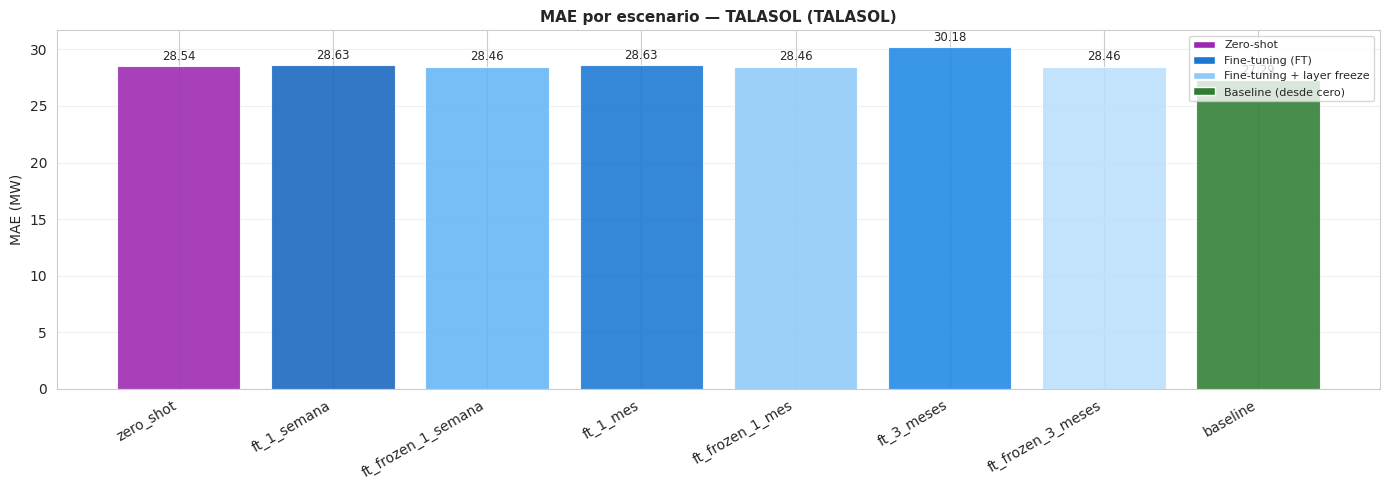

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures/mae_by_scenario.png
  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures/TALASOL_timeseries.png


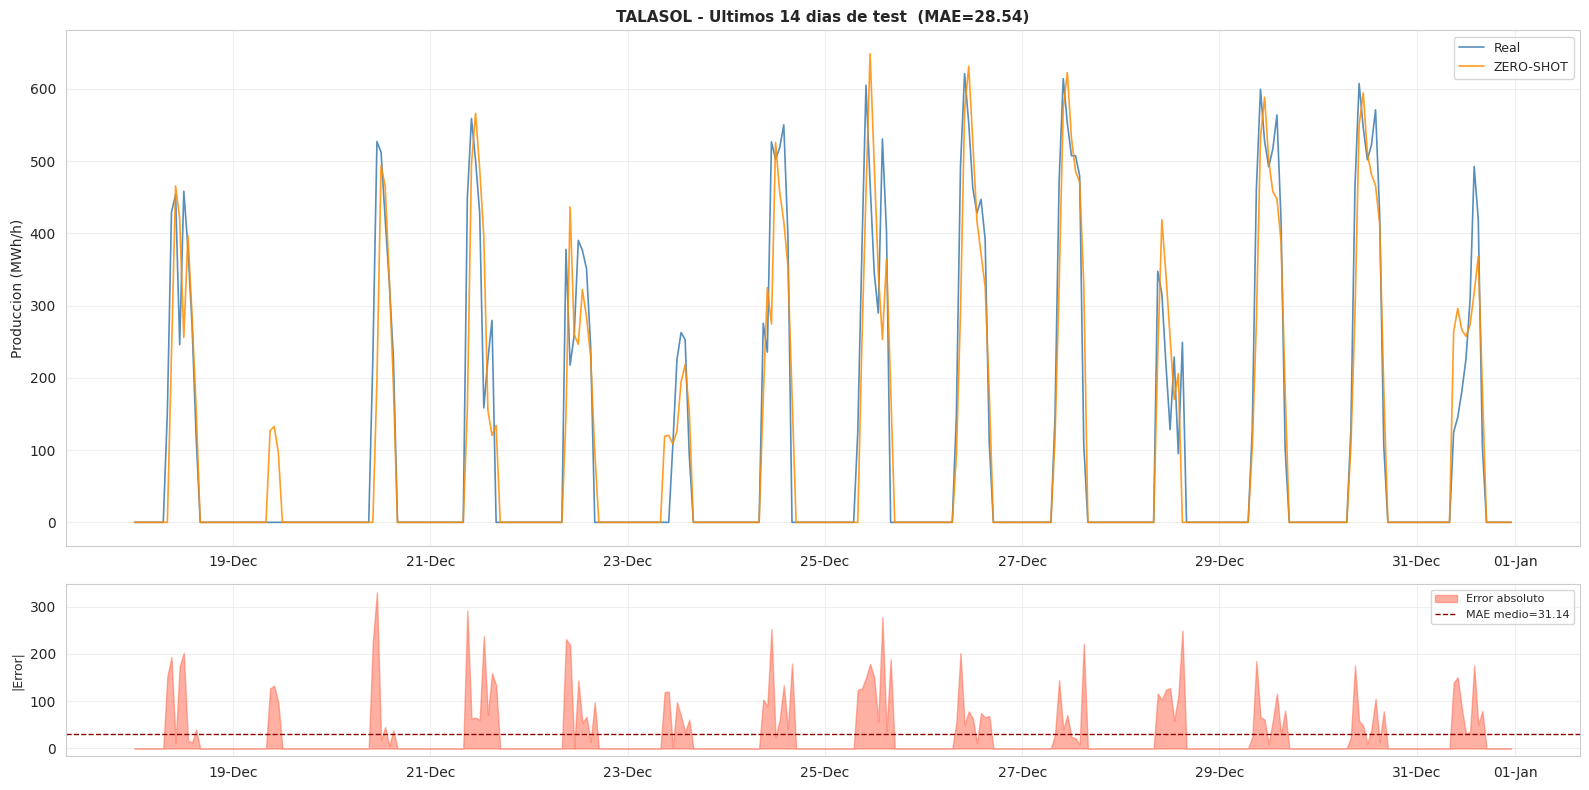

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures/TALASOL_timeseries.png


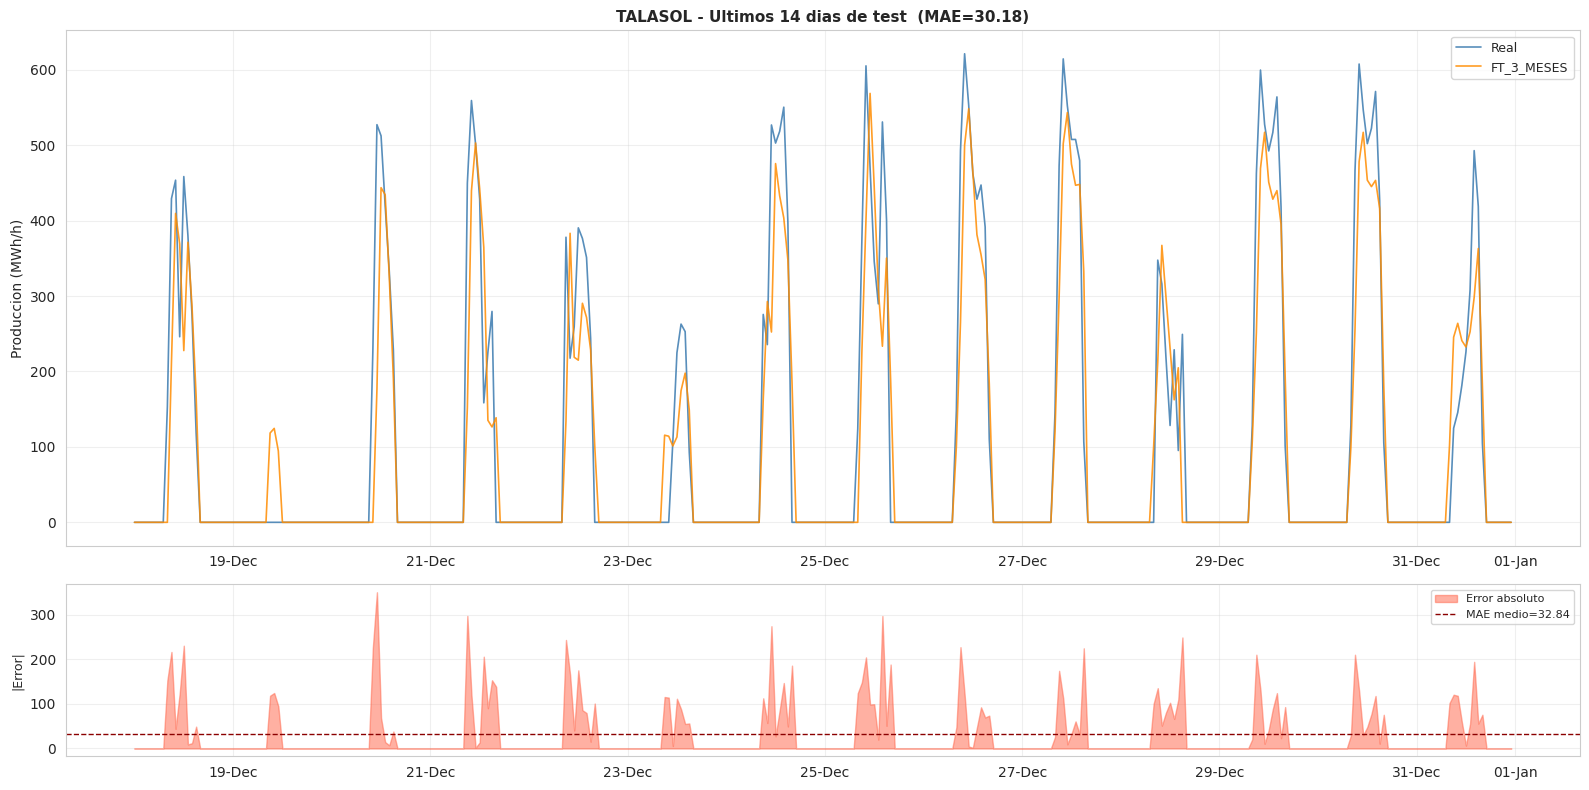

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures/TALASOL_timeseries.png


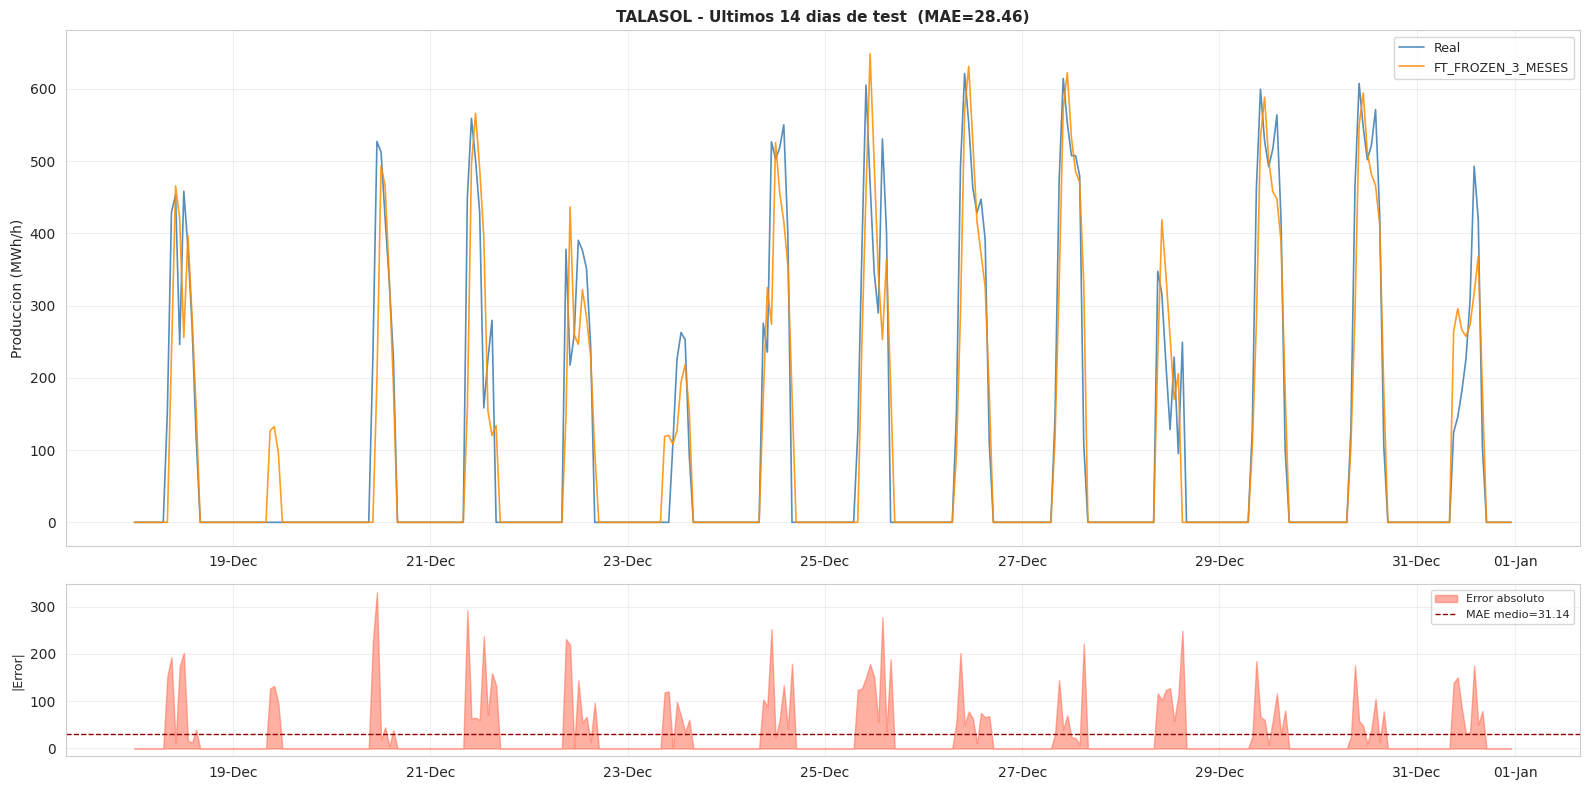

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures/TALASOL_timeseries.png


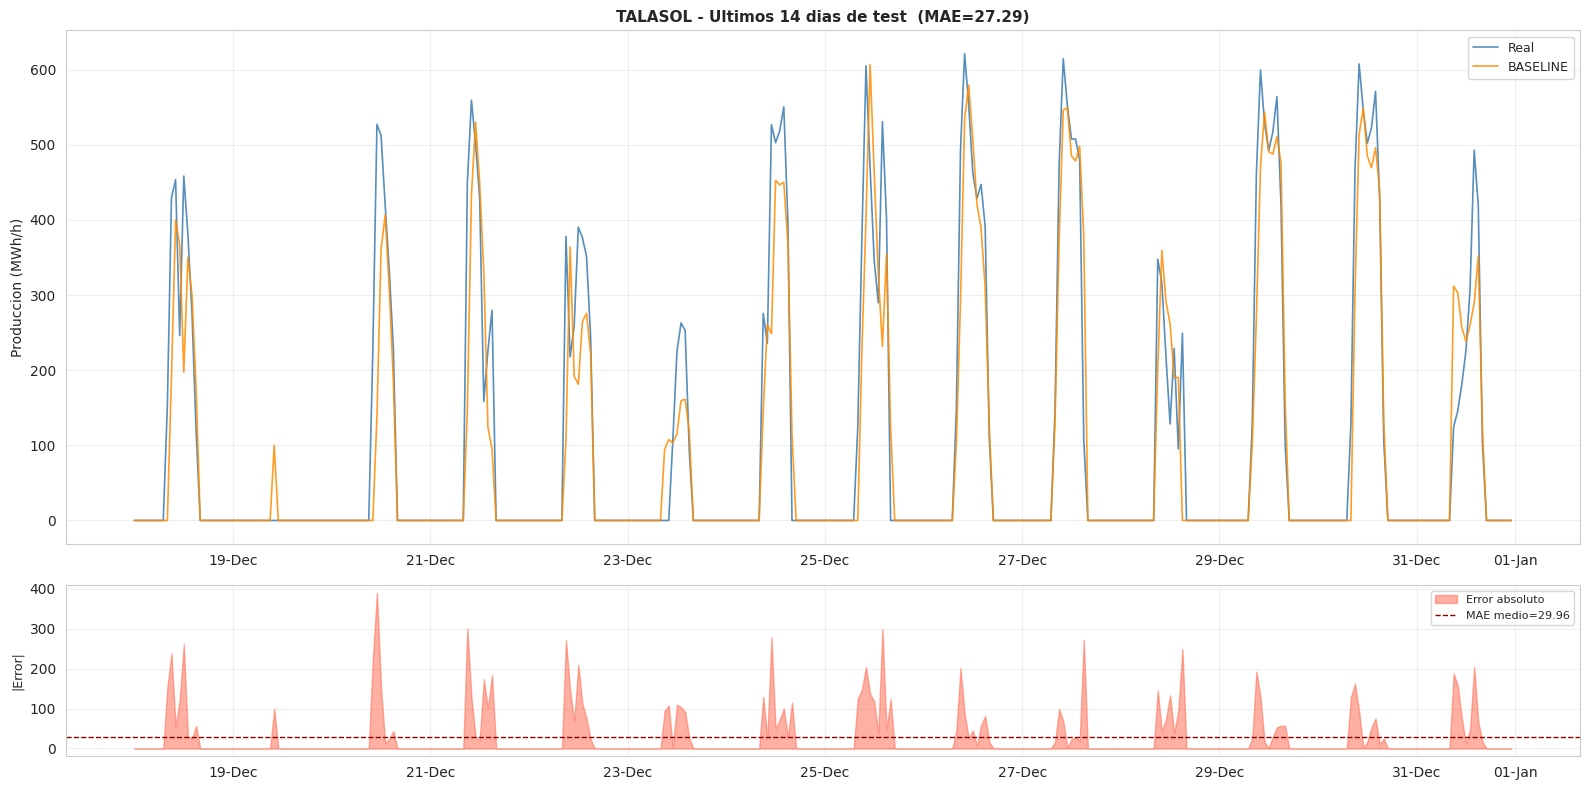

  Guardado: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures/TALASOL_learning_curves.png


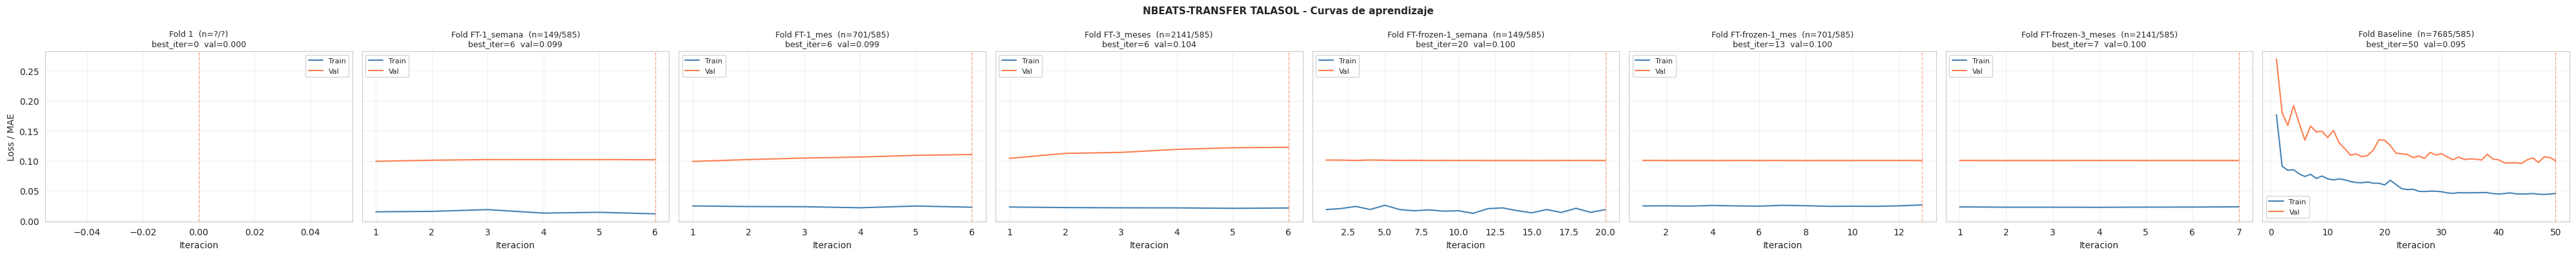


EXPERIMENTO 2 COMPLETADO
  Resultados: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats
  Figuras:    /content/drive/MyDrive/_UOC/tfm-solar-forecasting/results/ex2_transfer/nbeats/figures
  Checkpoints: /content/drive/MyDrive/_UOC/tfm-solar-forecasting/checkpoints/ex2_transfer/nbeats


In [11]:
# ============================================================================
# 7. VISUALIZACIÓN
# ============================================================================

print('[7/7] Visualización...')
fig_dir = RESULTS_DIR / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

# ── 7a. Bar plot MAE por escenario ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

scenario_labels = df_latest['scenario'].tolist()
mae_vals        = df_latest['MAE'].tolist()

# Paleta semántica: morado=zero-shot, azules=FT, azul claro=FT frozen, verde=baseline
color_map = {
    'zero_shot':          '#9C27B0',
    'ft_1_semana':        '#1565C0',
    'ft_frozen_1_semana': '#64B5F6',
    'ft_1_mes':           '#1976D2',
    'ft_frozen_1_mes':    '#90CAF9',
    'ft_3_meses':         '#1E88E5',
    'ft_frozen_3_meses':  '#BBDEFB',
    'baseline':           '#2E7D32',
}
colors = [color_map.get(s, '#BDBDBD') for s in scenario_labels]

bars = ax.bar(scenario_labels, mae_vals, color=colors, alpha=0.88, edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8.5)

ax.set_ylabel('MAE (MW)', fontsize=10)
ax.set_title(f'MAE por escenario — TALASOL ({PLANTA_TARGET})', fontsize=11, fontweight='bold')
ax.set_xticklabels(scenario_labels, rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#9C27B0', label='Zero-shot'),
    Patch(facecolor='#1976D2', label='Fine-tuning (FT)'),
    Patch(facecolor='#90CAF9', label='Fine-tuning + layer freeze'),
    Patch(facecolor='#2E7D32', label='Baseline (desde cero)'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / 'mae_by_scenario.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Guardado: {fig_dir}/mae_by_scenario.png')

# ── 7b. Series temporales ─────────────────────────────────────────────────────
# Zero-shot
plot_timeseries(df_pred_zs, PLANTA_TARGET, 'zero-shot', save_dir=fig_dir, days=14)

# Mejor FT normal (más datos)
if ft_preds:
    best_ft_name = max(ft_preds.keys(), key=lambda k: ft_scenarios[k])
    plot_timeseries(ft_preds[best_ft_name], PLANTA_TARGET, f'ft_{best_ft_name}',
                    save_dir=fig_dir, days=14)

# Mejor FT frozen (más datos)
if ft_frozen_preds:
    best_frz_name = max(ft_frozen_preds.keys(), key=lambda k: ft_scenarios[k])
    plot_timeseries(ft_frozen_preds[best_frz_name], PLANTA_TARGET, f'ft_frozen_{best_frz_name}',
                    save_dir=fig_dir, days=14)

# Baseline
plot_timeseries(df_pred_bl, PLANTA_TARGET, 'baseline', save_dir=fig_dir, days=14)

# ── 7c. Curvas de entrenamiento ───────────────────────────────────────────────
all_histories = [pretrain_hist]
for name, hist in ft_histories.items():
    all_histories.append({**hist, 'fold': f'FT-{name}'})
for name, hist in ft_frozen_histories.items():
    all_histories.append({**hist, 'fold': f'FT-frozen-{name}'})
all_histories.append({**baseline_hist, 'fold': 'Baseline'})

plot_learning_curves(
    all_histories, PLANTA_TARGET, 'nbeats-transfer',
    save_dir=fig_dir
)

print('\n' + '=' * 80)
print('EXPERIMENTO 2 COMPLETADO')
print(f'  Resultados: {RESULTS_DIR}')
print(f'  Figuras:    {fig_dir}')
print(f'  Checkpoints: {CHECKPOINTS_DIR}')
print('=' * 80)